In [39]:
import pandas as pd
from matplotlib import dates

In [2]:
# assign the column "Date" as the index and parse it as a datetime
df = pd.read_csv("data/starbucks.csv", index_col="Date", parse_dates=True)
print(df.head().index)
df.head()

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08'],
              dtype='datetime64[us]', name='Date', freq=None)


,Close,Volume
Date,,
2015-01-02,38.0061,6906098
2015-01-05,37.2781,11623796
2015-01-06,36.9748,7664340
2015-01-07,37.8848,9732554
2015-01-08,38.4961,13170548


In [3]:
# resample the daily data to annual data and calculate the mean for each year
"""
A	YE 	Year End
AS	YS	Year Start
Q	QE	Quarter End
M	ME	Month End
H	h	Hourly (case sensitivity cleanup)
"""
df.resample(rule='YE').mean() # with YE we can see the dates are the last day of the year

,Close,Volume
Date,,
2015-12-31,50.078100,8.649190e+06
2016-12-31,53.891732,9.300633e+06
2017-12-31,55.457310,9.296078e+06
2018-12-31,56.870005,1.122883e+07


In [4]:
def first_day(entry):
    # is there any entry?
    if len(entry) > 0:
        return entry.iloc[0]
    else:
        return None
    
display(df.resample(rule='YE').apply(first_day))
display(df.resample(rule='YE').first())


,Close,Volume
Date,,
2015-12-31,38.0061,6906098
2016-12-31,55.0780,13521544
2017-12-31,53.1100,7809307
2018-12-31,56.3243,7215978


,Close,Volume
Date,,
2015-12-31,38.0061,6906098
2016-12-31,55.0780,13521544
2017-12-31,53.1100,7809307
2018-12-31,56.3243,7215978


<Axes: title={'center': 'Average closing price per year'}, xlabel='Year', ylabel='Price ($)'>

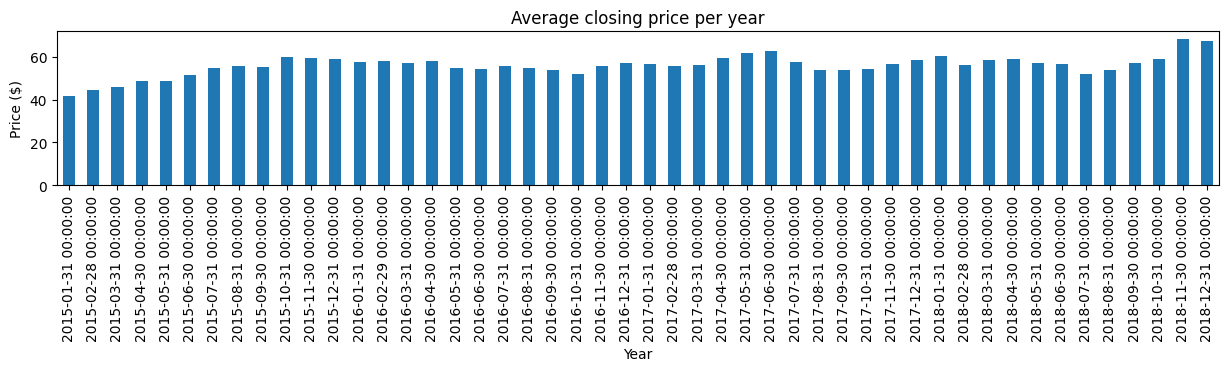

In [5]:
df["Close"].resample(rule='ME').max().plot.bar(
    figsize=(15, 2), 
    title="Average closing price per year", 
    ylabel="Price ($)", 
    xlabel="Year")

In [10]:
display(df.shift(2).head()) # shift the data down by 2 rows, the first two rows will be NaN
display(df.shift(-2).tail()) # shift the data up by 2 rows, the last two rows will be NaN

,Close,Volume
Date,,
2015-01-02,NaN,NaN
2015-01-05,NaN,NaN
2015-01-06,38.0061,6906098.0
2015-01-07,37.2781,11623796.0
2015-01-08,36.9748,7664340.0


,Close,Volume
Date,,
2018-12-24,63.20,11308081.0
2018-12-26,63.39,7712127.0
2018-12-27,64.40,7690183.0
2018-12-28,NaN,NaN
2018-12-31,NaN,NaN


In [ ]:
display(df.head())
df.shift(periods=1, freq="ME").head() # shift the data down to the end of the month

,Close,Volume
Date,,
2015-01-02,38.0061,6906098
2015-01-05,37.2781,11623796
2015-01-06,36.9748,7664340
2015-01-07,37.8848,9732554
2015-01-08,38.4961,13170548


,Close,Volume
Date,,
2015-01-31,38.0061,6906098
2015-01-31,37.2781,11623796
2015-01-31,36.9748,7664340
2015-01-31,37.8848,9732554
2015-01-31,38.4961,13170548


In [ ]:
display(df.head())
df.rolling(window=3).mean().head() # calculate the mean value for the current and previous 2 rows

,Close,Volume
Date,,
2015-01-02,38.0061,6906098
2015-01-05,37.2781,11623796
2015-01-06,36.9748,7664340
2015-01-07,37.8848,9732554
2015-01-08,38.4961,13170548


,Close,Volume
Date,,
2015-01-02,NaN,NaN
2015-01-05,NaN,NaN
2015-01-06,37.419667,8.731411e+06
2015-01-07,37.379233,9.673563e+06
2015-01-08,37.785233,1.018915e+07


<Axes: xlabel='Date', ylabel='Price ($)'>

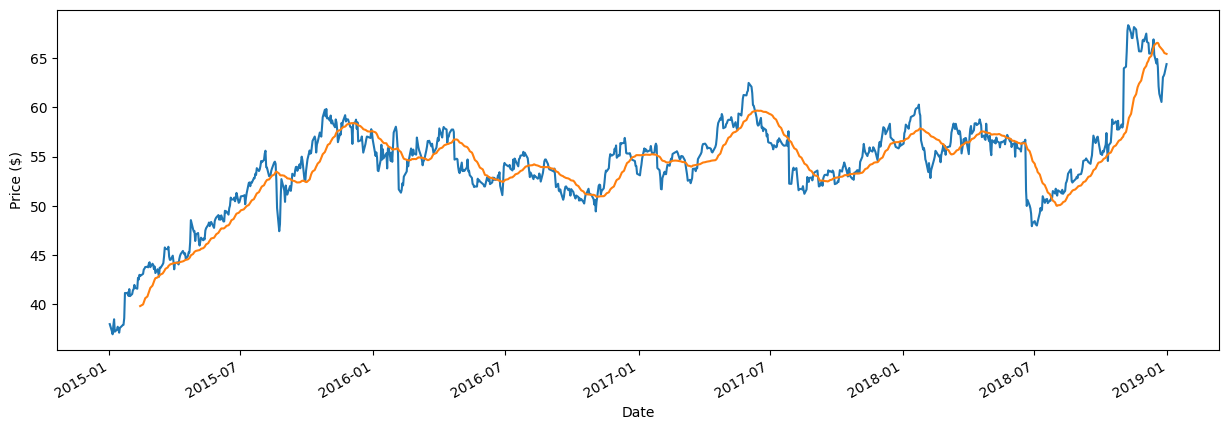

In [22]:
df["Close"].plot(figsize=(15, 5), ylabel="Price ($)", xlabel="Date")
df.rolling(window=30).mean()["Close"].plot(figsize=(15, 5))

In [ ]:
# with expanding we can calculate the mean value for all the previous rows and the current row
df["Close"].expanding().mean()

Date
2015-01-02    38.006100
2015-01-05    37.642100
2015-01-06    37.419667
2015-01-07    37.535950
2015-01-08    37.727980
                ...    
2018-12-24    54.032419
2018-12-26    54.041439
2018-12-27    54.050561
2018-12-28    54.059854
2018-12-31    54.070133
Name: Close, Length: 1006, dtype: float64

<Axes: xlabel='Date', ylabel='Price ($)'>

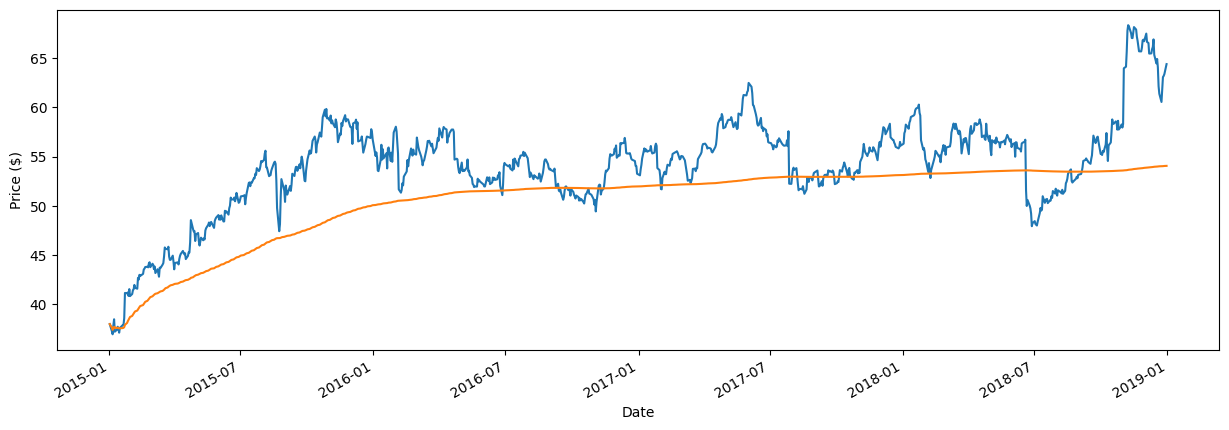

In [27]:
df["Close"].plot(figsize=(15, 5), ylabel="Price ($)", xlabel="Date")
df["Close"].expanding().mean().plot(figsize=(15, 5), ylabel="Price ($)", xlabel="Date")

[Text(0.5, 0, 'Date'),
 Text(0, 0.5, 'Price ($)'),
 Text(0.5, 1.0, 'Closing price with expanding mean')]

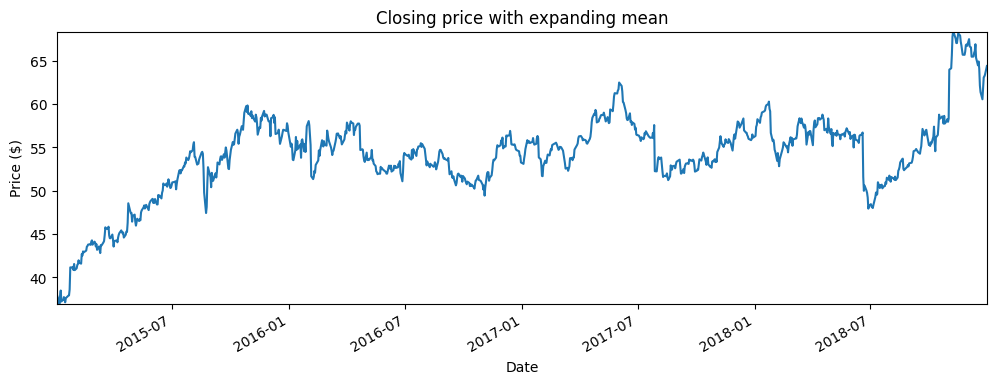

In [38]:
ax = df["Close"].plot(figsize=(12, 4), xlim=["2015-01-01", "2018-01-01"])
ax.autoscale(axis="both", tight=True) # autoscale the x and y axis to frame the data
ax.set(xlabel="Date", ylabel="Price ($)", title="Closing price with expanding mean")

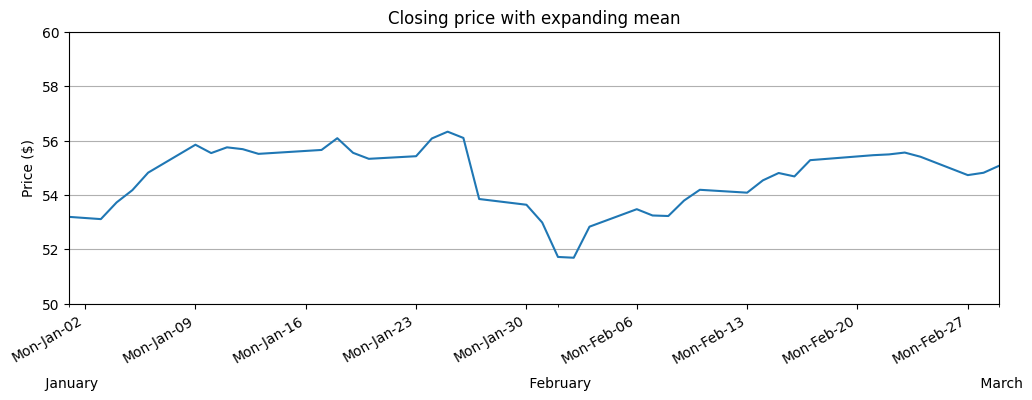

In [58]:
ax = df["Close"].plot(
    xlim=["2017-01-01", "2017-03-01"], 
    ylim=(50, 60),
    figsize=(12, 4), ylabel="Price ($)", 
    xlabel="Date", 
    title="Closing price with expanding mean")
ax.set(xlabel="")
ax.xaxis.set_major_locator(dates.WeekdayLocator(byweekday=0)) # set the major ticks to be every Monday
ax.xaxis.set_major_formatter(dates.DateFormatter("%a-%b-%d")) # set the format of the major ticks to be "Day-Month-Date"
ax.xaxis.set_minor_locator(dates.MonthLocator()) # set the minor ticks to be every month
ax.xaxis.set_minor_formatter(dates.DateFormatter("\n\n\n\n %B")) # set the format of the minor ticks to be "Month")
ax.yaxis.grid(True)